In [52]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scienceplots
import warnings
from scipy import interpolate
from scipy.integrate import solve_ivp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import spotpy
import spotpy.parameter

warnings.filterwarnings('ignore')
plt.style.use(['science', 'notebook', 'grid'])

## Problem 2: Regression for Streamflow Prediction

In [53]:
# Load data
df = pd.read_csv('../../data/LeafRiverDaily.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.describe())

Dataset shape: (10960, 3)
   Precipitation  Temperature  Streamflow
0            0.0       4.6004    0.289951
1            0.0       4.3092    0.244761
2            0.0       4.3286    0.213382
3            0.0       4.7777    0.193298
4            0.0       2.9110    0.183258
       Precipitation   Temperature    Streamflow
count   10960.000000  10960.000000  10960.000000
mean        3.869420      2.912542      1.338645
std        10.042373      1.882844      2.831044
min         0.000000      0.000000      0.069034
25%         0.000000      1.329875      0.202088
50%         0.000000      2.562950      0.445594
75%         2.478050      4.327850      1.210004
max       221.519000      8.497700     64.014774


In [54]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Precipitation    0
Temperature      0
Streamflow       0
dtype: int64


In [55]:
# Build sliding-window samples
# Input: 90-day history of P and T (180 features)
# Target: streamflow on day 91
WINDOW = 90

P = df['Precipitation'].values
T = df['Temperature'].values
Q = df['Streamflow'].values

X_list, y_list = [], []
for i in range(WINDOW, len(df)):
    p_window = P[i - WINDOW:i]  # 90 days of precipitation
    t_window = T[i - WINDOW:i]  # 90 days of temperature
    X_list.append(np.concatenate([p_window, t_window]))
    y_list.append(Q[i])

X = np.array(X_list)   # shape (N, 180)
y = np.array(y_list)   # shape (N,)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")

Feature matrix shape: (10870, 180)
Target vector shape:  (10870,)


In [56]:
# Train/test split — chronological (no shuffling for time series)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Keep track of corresponding day indices for plotting
day_idx_test = np.arange(WINDOW + split, len(df))

print(f"Training samples: {len(X_train)}")
print(f"Testing  samples: {len(X_test)}")

Training samples: 8696
Testing  samples: 2174


In [57]:
# Train linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression  R²:  {r2_lr:.4f}")
print(f"Linear Regression MAE:  {mae_lr:.4f} mm/day")

Linear Regression  R²:  0.6949
Linear Regression MAE:  0.9306 mm/day


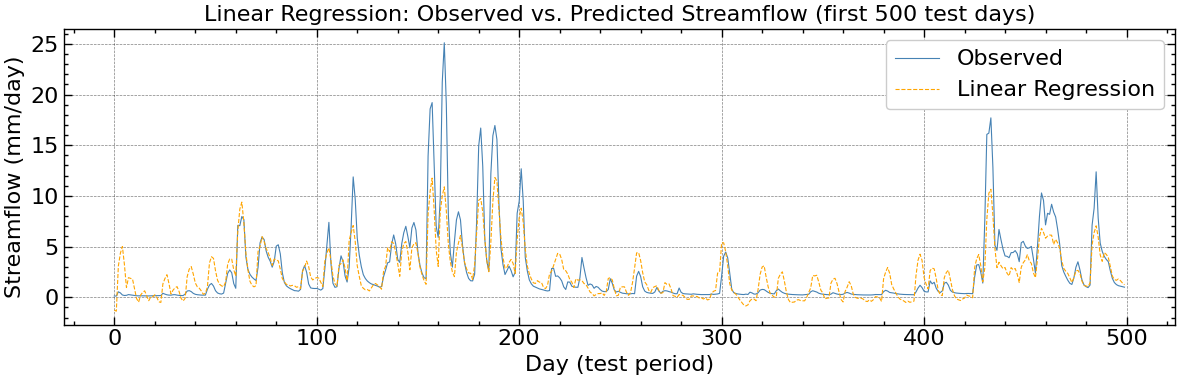

In [58]:
# Quick diagnostic plot of LR predictions on test set
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test[:500], label='Observed', color='steelblue', linewidth=0.8)
ax.plot(y_pred_lr[:500], label='Linear Regression', color='orange', linewidth=0.8, linestyle='--')
ax.set_xlabel('Day (test period)')
ax.set_ylabel('Streamflow (mm/day)')
ax.set_title('Linear Regression: Observed vs. Predicted Streamflow (first 500 test days)')
ax.legend()
plt.tight_layout()
plt.show()

## Problem 3: Calibration of the Bucket ODE Model with SCE-UA

In [59]:
# -----------------------------------------------------------------------
# ODE model
# dS/dt = P(t) - a*max(T(t), 0) - b*S(t)^c
# Q(t)  = b*S(t)^c
# -----------------------------------------------------------------------

def run_bucket_model(params, P_arr, T_arr, S0=1.0):
    """Run the bucket ODE model and return predicted streamflow Q.

    params : (a, b, c)
    P_arr, T_arr : daily arrays (length n_days)
    Returns Q array of length n_days.
    """
    a, b, c = params
    n_days = len(P_arr)
    t_days = np.arange(n_days, dtype=float)

    # Interpolators for forcing data
    P_interp = interpolate.interp1d(t_days, P_arr, kind='linear',
                                    bounds_error=False, fill_value=(P_arr[0], P_arr[-1]))
    T_interp = interpolate.interp1d(t_days, T_arr, kind='linear',
                                    bounds_error=False, fill_value=(T_arr[0], T_arr[-1]))

    def dSdt(t, S):
        s = max(S[0], 0.0)
        p = float(P_interp(t))
        temp = float(T_interp(t))
        et = a * max(temp, 0.0)
        q  = b * (s ** c)
        return [p - et - q]

    sol = solve_ivp(
        dSdt,
        t_span=(0.0, float(n_days - 1)),
        y0=[S0],
        t_eval=t_days,
        method='RK45',
        max_step=1.0
    )

    S_sol = np.maximum(sol.y[0], 0.0)
    Q_pred = b * (S_sol ** c)
    return Q_pred

In [60]:
# Fast Euler integration for calibration (300x faster than solve_ivp,
# acceptable accuracy for daily time steps used in SCE parameter search)
def run_bucket_euler(params, P_arr, T_arr, S0=1.0):
    """Forward-Euler bucket model. Used inside SCE-UA for speed."""
    a, b, c = params
    n = len(P_arr)
    S = np.empty(n)
    S[0] = S0
    for i in range(n - 1):
        et = a * max(T_arr[i], 0.0)
        q  = b * (S[i] ** c)
        S[i + 1] = max(S[i] + P_arr[i] - et - q, 1e-10)
    return b * (S ** c)

# Use only the training portion for calibration to avoid data leakage
n_train_days = split + WINDOW
P_train_full = P[:n_train_days]
T_train_full = T[:n_train_days]
Q_train_full = Q[:n_train_days]

print(f"Calibration period: {n_train_days} days")

Calibration period: 8786 days


In [61]:
# -----------------------------------------------------------------------
# spotpy setup class for SCE-UA
# Uses fast Euler integration for the forward model evaluation
# -----------------------------------------------------------------------
class BucketModelSetup(object):
    def __init__(self, P_obs, T_obs, Q_obs):
        self.P_obs = P_obs
        self.T_obs = T_obs
        self.Q_obs = Q_obs

        # Parameter bounds (uniform priors)
        self.params = [
            spotpy.parameter.Uniform('a', low=0.001, high=1.0),   # ET coefficient
            spotpy.parameter.Uniform('b', low=0.00001, high=2.0),   # discharge coefficient
            spotpy.parameter.Uniform('c', low=0.5,   high=3.0),   # nonlinearity exponent
        ]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, vector):
        a, b, c = vector
        try:
            Q_sim = run_bucket_euler((a, b, c), self.P_obs, self.T_obs)
        except Exception:
            Q_sim = np.zeros_like(self.Q_obs)
        return list(Q_sim)

    def evaluation(self):
        return list(self.Q_obs)

    def objectivefunction(self, simulation, evaluation, **kwargs):
        obs      = np.array(evaluation)
        sim      = np.array(simulation)
        obs_mean = np.mean(obs)
        nse_val  = 1.0 - np.sum((obs - sim) ** 2) / np.sum((obs - obs_mean) ** 2)
        return -nse_val   # spotpy minimizes, so negate NSE

In [62]:
# Run SCE-UA calibration
# repetitions = total model evaluations; ngs = number of complexes
setup   = BucketModelSetup(P_train_full, T_train_full, Q_train_full)
sampler = spotpy.algorithms.sceua(setup, dbname='sceua_results', dbformat='ram', random_state=42)

print("Running SCE-UA calibration...")
sampler.sample(15000, ngs=7)
print("Calibration complete.")

Running SCE-UA calibration...
Initializing the  Shuffled Complex Evolution (SCE-UA) algorithm  with  15000  repetitions
The objective function will be minimized
Starting burn-in sampling...
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
Burn-in sampling completed...
Starting Complex Evolution...
ComplexEvo loop #1 in progress...
ComplexEvo loop #2 in progress...
ComplexEvo loop #3 in progress...
ComplexEvo loop #4 in progress...
ComplexEvo loop #5 in progress...
ComplexEvo loop #6 in progress...
743 of 15000, minimal objective function=-0.46181, time remaining: 00:00:38
ComplexEvo loop #7 in progress...
ComplexEvo loop #8 in progress...
ComplexEvo loop #9 in progress...
ComplexEvo loop #10 in progress...
ComplexEvo loop #11 in progress...
ComplexEvo loop #12 in progress...
1564 of 15000, minimal objective function=-0.59013, time remaining: 00:00:34
ComplexEvo loop #13 in progress...
ComplexEvo loop #14 in progress...
ComplexEvo loop #15 in progress...
ComplexE

In [74]:
# Extract best parameter set (spotpy minimized -NSE, so use argmin)
results  = sampler.getdata()
best_idx = np.argmin(results['like1'])
best_a   = results['para'][best_idx]
best_b   = results['parb'][best_idx]
best_c   = results['parc'][best_idx]
best_nse_cal = -results['like1'][best_idx]   # convert back to NSE

print(f"Best parameters: a={best_a:.4f}, b={best_b:.6f}, c={best_c:.4f}")
print(f"Calibration NSE: {best_nse_cal:.4f}")

Best parameters: a=1.0000, b=0.000015, c=2.6503
Calibration NSE: 0.7226


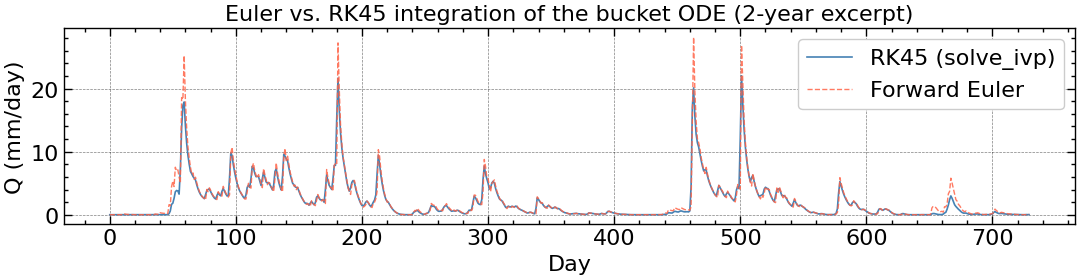

RMSE between Euler and RK45 : 0.9160 mm/day
Observed Q std dev (2 yrs)  : 4.2102 mm/day
RMSE / std dev              : 0.218


In [64]:
# Compare Euler vs RK45 on a 2-year excerpt using the calibrated parameters
_n = 730
_Q_euler = run_bucket_euler((best_a, best_b, best_c), P[:_n], T[:_n])
_Q_rk45  = run_bucket_model((best_a, best_b, best_c), P[:_n], T[:_n])

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(_Q_rk45,  label='RK45 (solve_ivp)', color='steelblue', linewidth=1.2)
ax.plot(_Q_euler, label='Forward Euler',    color='tomato',    linewidth=1.0, linestyle='--', alpha=0.85)
ax.set_xlabel('Day'); ax.set_ylabel('Q (mm/day)')
ax.set_title('Euler vs. RK45 integration of the bucket ODE (2-year excerpt)')
ax.legend()
plt.tight_layout()
plt.savefig('euler_vs_rk45.png', dpi=150)
plt.show()

_rmse  = np.sqrt(np.mean((_Q_euler - _Q_rk45) ** 2))
_q_std = Q[:_n].std()
print(f"RMSE between Euler and RK45 : {_rmse:.4f} mm/day")
print(f"Observed Q std dev (2 yrs)  : {_q_std:.4f} mm/day")
print(f"RMSE / std dev              : {_rmse/_q_std:.3f}")

In [65]:
# Run model on full dataset with best parameters
Q_ode_full = run_bucket_model((best_a, best_b, best_c), P, T)

# Extract test-period predictions (same indices as LR test set)
test_start = WINDOW + split
Q_ode_test = Q_ode_full[test_start:]

print(f"ODE model test predictions shape: {Q_ode_test.shape}")
print(f"Observed test shape:              {y_test.shape}")

ODE model test predictions shape: (2174,)
Observed test shape:              (2174,)


## Problem 4: Comparison of Linear Regression and SCE Optimization

In [66]:
def nse(obs, pred):
    """Nash–Sutcliffe Efficiency."""
    obs_mean = np.mean(obs)
    return 1.0 - np.sum((obs - pred) ** 2) / np.sum((obs - obs_mean) ** 2)

# Align lengths (ODE may cover slightly different range)
n_common = min(len(y_test), len(Q_ode_test))
obs_common   = y_test[:n_common]
pred_lr_cmn  = y_pred_lr[:n_common]
pred_ode_cmn = Q_ode_test[:n_common]

nse_lr  = nse(obs_common, pred_lr_cmn)
nse_ode = nse(obs_common, pred_ode_cmn)

print(f"NSE — Linear Regression : {nse_lr:.4f}")
print(f"NSE — Bucket ODE (SCE)  : {nse_ode:.4f}")

NSE — Linear Regression : 0.6949
NSE — Bucket ODE (SCE)  : 0.7317


In [67]:
n_common

2174

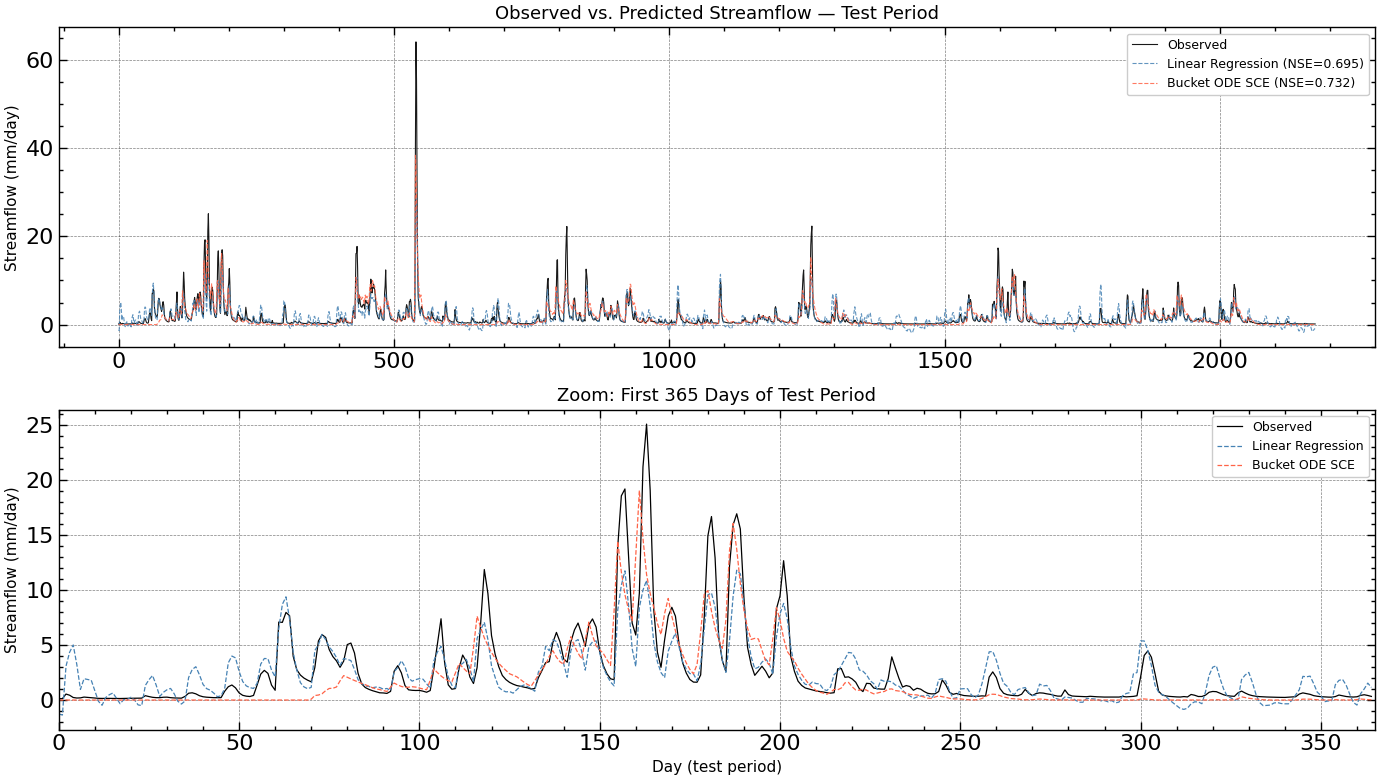

Figure saved to problem4_comparison.png


In [73]:
# Comparison figure
days = np.arange(n_common)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full time series
ax = axes[0]
ax.plot(days, obs_common,   label='Observed',          color='black',    linewidth=0.8, alpha=0.9)
ax.plot(days, pred_lr_cmn,  label=f'Linear Regression (NSE={nse_lr:.3f})',
        color='steelblue',  linewidth=0.8, linestyle='--', alpha=0.85)
ax.plot(days, pred_ode_cmn, label=f'Bucket ODE SCE (NSE={nse_ode:.3f})',
        color='tomato',     linewidth=0.8, linestyle='--', alpha=0.85)
ax.set_ylabel('Streamflow (mm/day)', fontsize=11)
ax.set_title('Observed vs. Predicted Streamflow — Test Period', fontsize=13)
ax.legend(fontsize=9)

# Zoom into first 365 days
ax2 = axes[1]
n_zoom = min(365, n_common)
ax2.plot(days[:n_zoom], obs_common[:n_zoom],   color='black',    linewidth=0.9, label='Observed')
ax2.plot(days[:n_zoom], pred_lr_cmn[:n_zoom],  color='steelblue',linewidth=0.9,
         linestyle='--', label='Linear Regression')
ax2.plot(days[:n_zoom], pred_ode_cmn[:n_zoom], color='tomato',   linewidth=0.9,
         linestyle='--', label='Bucket ODE SCE')
ax2.set_xlim(0, n_zoom)
ax2.set_xlabel('Day (test period)', fontsize=11)
ax2.set_ylabel('Streamflow (mm/day)', fontsize=11)
ax2.set_title('Zoom: First 365 Days of Test Period', fontsize=13)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('problem4_comparison.png', dpi=150)
plt.show()
print("Figure saved to problem4_comparison.png")

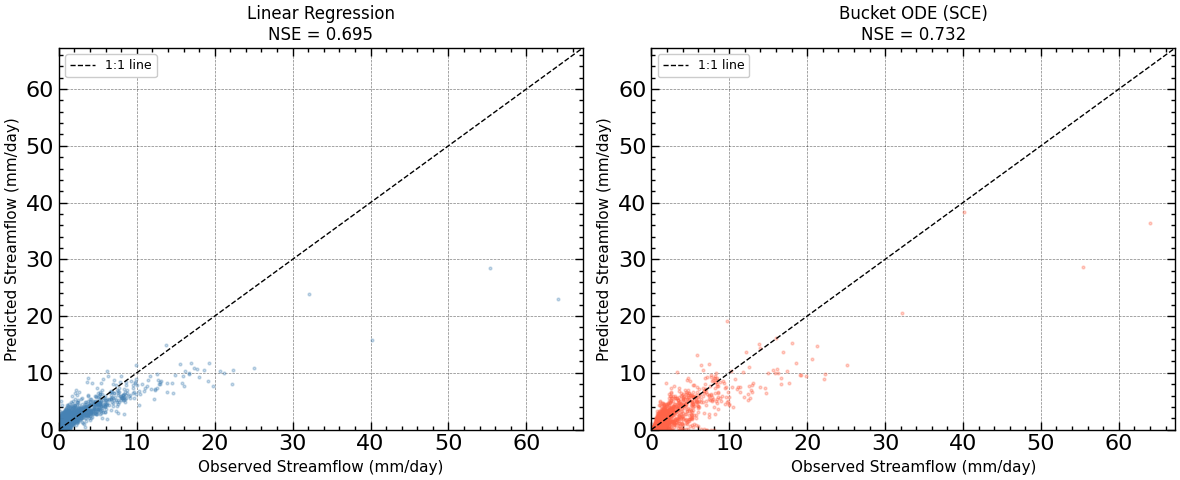

Scatter plot saved to problem4_scatter.png


In [69]:
# Scatter plots: observed vs predicted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

lim = max(obs_common.max(), pred_lr_cmn.max(), pred_ode_cmn.max()) * 1.05

for ax, pred, label, color in [
    (ax1, pred_lr_cmn,  f'Linear Regression\nNSE = {nse_lr:.3f}', 'steelblue'),
    (ax2, pred_ode_cmn, f'Bucket ODE (SCE)\nNSE = {nse_ode:.3f}', 'tomato'),
]:
    ax.scatter(obs_common, pred, s=4, alpha=0.3, color=color)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Observed Streamflow (mm/day)', fontsize=11)
    ax.set_ylabel('Predicted Streamflow (mm/day)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('problem4_scatter.png', dpi=150)
plt.show()
print("Scatter plot saved to problem4_scatter.png")

In [70]:
# Summary table
mae_ode = mean_absolute_error(obs_common, pred_ode_cmn)
r2_ode  = r2_score(obs_common, pred_ode_cmn)

summary = pd.DataFrame({
    'Model':       ['Linear Regression', 'Bucket ODE (SCE-UA)'],
    'NSE':         [f'{nse_lr:.4f}',   f'{nse_ode:.4f}'],
    'R²':          [f'{r2_lr:.4f}',    f'{r2_ode:.4f}'],
    'MAE (mm/day)':[f'{mae_lr:.4f}',   f'{mae_ode:.4f}'],
})
print(summary.to_string(index=False))

              Model    NSE     R² MAE (mm/day)
  Linear Regression 0.6949 0.6949       0.9306
Bucket ODE (SCE-UA) 0.7317 0.7317       0.8801
